In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from src.data_loader import load_raw_data, build_dataset
from src.features import build_features

sns.set_theme(style='whitegrid', font_scale=1.1)
pd.set_option('display.max_columns', 50)

print("All imports OK!")

All imports OK!


In [2]:
data = load_raw_data()
df   = build_dataset(data)
df   = build_features(df)

print(f"Final shape: {df.shape}")
df.head(3)

circuits                       77 rows   9 cols
constructors                  212 rows   5 cols
constructor_standings      13,391 rows   7 cols
driver_standings           34,863 rows   7 cols
drivers                       861 rows   9 cols
lap_times                 589,081 rows   6 cols
pit_stops                  11,371 rows   7 cols
qualifying                 10,494 rows   9 cols
races                       1,125 rows  18 cols
results                    26,759 rows  18 cols
status                        139 rows   2 cols

  All files loaded successfully.

--- Building merged dataset ---

  After core merge:        (26759, 38)
  After standings merge:   (26759, 44)
  After qualifying merge:  (26759, 47)
  After pit stops merge:   (26759, 48)
  Final shape:    (26759, 48)
  Years:          1950 – 2024
  Unique races:   1,125
  Unique drivers: 861
  Podium rate:    12.7%
  DNF rate:       43.9%
  Points rate:    30.5%
  Saved → data/f1_merged.csv

=== Feature Engineering ===

  Adding ci

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,round,circuitId,name,date,circuitRef,country,...,is_dnf,podium,in_points,driver_standing_pts,driver_standing_pos,driver_wins_so_far,constructor_standing_pts,constructor_standing_pos,constructor_wins_so_far,quali_position,best_quali_sec,quali_gap_to_pole,pit_stop_count,circuit_win_rate,circuit_podium_rate,circuit_avg_finish,circuit_races_count,driver_avg_finish_last3,driver_avg_finish_last5,constructor_avg_pts_last3,constructor_avg_pts_last5,driver_experience,grid_vs_quali,season_progress,pts_gap_to_leader
0,371,36,1,1,2.0,4,3.0,3,3,6.0,58,+18.595,5147365.0,20.0,3.0,1:26.351,221.083,1,2007,1,1,Australian Grand Prix,2007-03-18,albert_park,Australia,...,0,1,1,6.0,3.0,0.0,14.0,11.0,0.0,4.0,85.577,0.251,0,NaN,NaN,NaN,0,NaN,NaN,5.333333,6.4,0,0.0,0.058824,4.0
1,392,37,1,1,2.0,4,2.0,2,2,8.0,56,+17.557,5552487.0,22.0,1.0,1:36.701,206.355,1,2007,2,2,Malaysian Grand Prix,2007-04-08,sepang,Malaysia,...,0,1,1,14.0,3.0,0.0,32.0,11.0,1.0,4.0,94.650,0.593,0,NaN,NaN,NaN,0,3.0,3.0,10.000000,7.2,1,0.0,0.117647,4.0
2,414,38,1,1,2.0,2,2.0,2,2,8.0,57,+2.360,5609875.0,18.0,2.0,1:34.270,206.674,1,2007,3,3,Bahrain Grand Prix,2007-04-15,bahrain,Bahrain,...,0,1,1,22.0,3.0,0.0,44.0,11.0,1.0,2.0,91.752,0.393,0,NaN,NaN,NaN,0,2.5,2.5,12.666667,9.6,2,0.0,0.176471,0.0


In [3]:
new_features = [
    'circuit_win_rate', 'circuit_podium_rate', 'circuit_avg_finish',
    'circuit_races_count', 'driver_avg_finish_last3', 'driver_avg_finish_last5',
    'constructor_avg_pts_last3', 'constructor_avg_pts_last5',
    'driver_experience', 'grid_vs_quali', 'season_progress', 'pts_gap_to_leader'
]

print(f"{'Feature':<35} {'Non-null %':<12} {'Mean':<10} {'Min':<10} {'Max'}")
print("-" * 75)
for col in new_features:
    non_null = df[col].notna().mean() * 100
    mean     = df[col].mean()
    min_val  = df[col].min()
    max_val  = df[col].max()
    print(f"  {col:<33} {non_null:>6.1f}%     {mean:>8.2f}   {min_val:>8.2f}   {max_val:>8.2f}")

Feature                             Non-null %   Mean       Min        Max
---------------------------------------------------------------------------
  circuit_win_rate                    69.4%         0.04       0.00       1.00
  circuit_podium_rate                 69.4%         0.14       0.00       1.00
  circuit_avg_finish                  69.4%        12.28       1.00      39.00
  circuit_races_count                100.0%         2.67       0.00      20.00
  driver_avg_finish_last3             96.8%        12.63       1.00      39.00
  driver_avg_finish_last5             96.8%        12.64       1.00      39.00
  constructor_avg_pts_last3           98.7%         4.41       0.00      45.33
  constructor_avg_pts_last5           98.7%         4.37       0.00      44.40
  driver_experience                  100.0%        65.91       0.00     403.00
  grid_vs_quali                       39.2%        -0.16     -28.00      23.00
  season_progress                    100.0%         0.53   

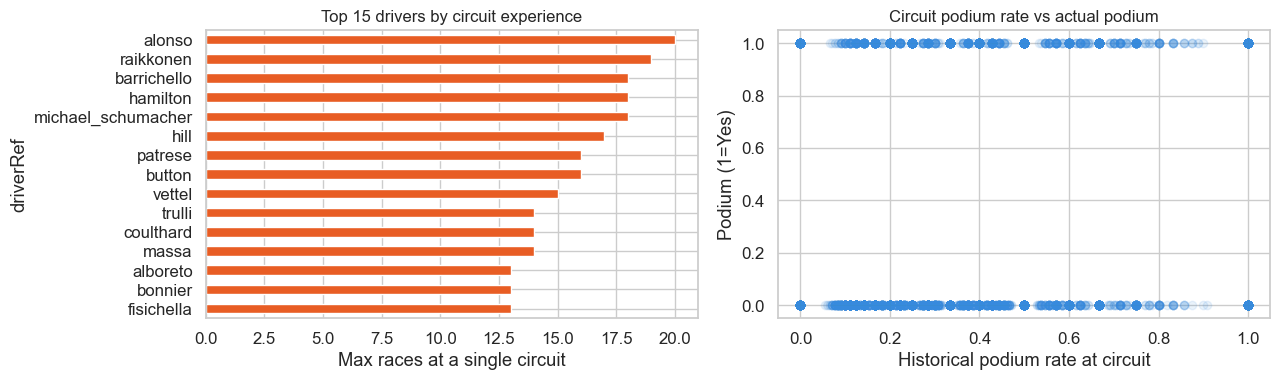

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# drivers with most circuit experience
circuit_exp = df.groupby('driverRef')['circuit_races_count'].max().sort_values(ascending=False).head(15)
circuit_exp.plot(kind='barh', ax=axes[0], color='#E85D24')
axes[0].set_title('Top 15 drivers by circuit experience', fontsize=12)
axes[0].set_xlabel('Max races at a single circuit')
axes[0].invert_yaxis()

# circuit podium rate vs actual podium
circuit_data = df[df['circuit_podium_rate'].notna()]
axes[1].scatter(
    circuit_data['circuit_podium_rate'],
    circuit_data['podium'],
    alpha=0.1, color='#378ADD'
)
axes[1].set_title('Circuit podium rate vs actual podium', fontsize=12)
axes[1].set_xlabel('Historical podium rate at circuit')
axes[1].set_ylabel('Podium (1=Yes)')

plt.tight_layout()
plt.show()

/var/folders/w7/_97xxd591fz9hc4m2q3ftsh40000gn/T/ipykernel_28683/135342604.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


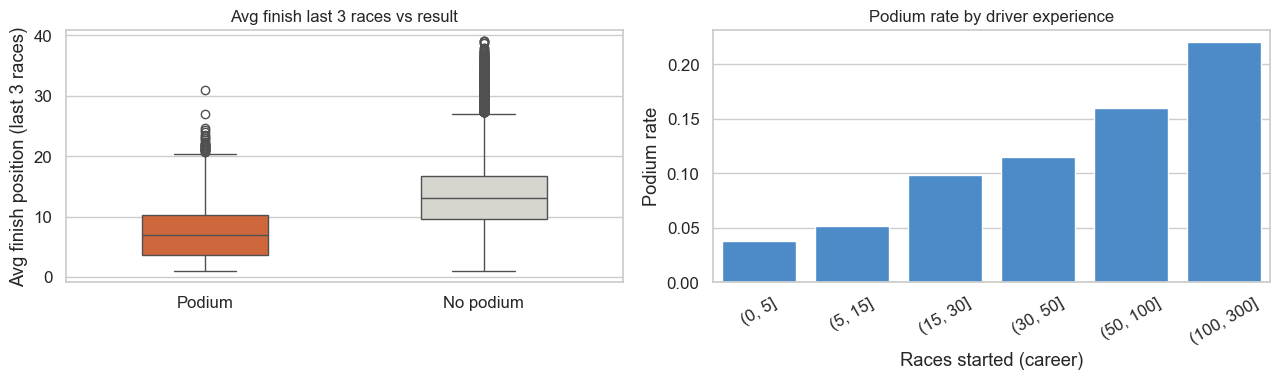


Avg finish last 3 — Podium:     7.57
Avg finish last 3 — No podium:  13.39


In [5]:
# compare avg finish last 3 races for podium vs non-podium
form_data = df[df['driver_avg_finish_last3'].notna()].copy()
form_data['Result'] = form_data['podium'].map({1: 'Podium', 0: 'No podium'})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# box plot
sns.boxplot(
    data=form_data, x='Result', y='driver_avg_finish_last3',
    palette={'Podium': '#E85D24', 'No podium': '#D8D6CC'},
    order=['Podium', 'No podium'],
    ax=axes[0], width=0.45
)
axes[0].set_title('Avg finish last 3 races vs result', fontsize=12)
axes[0].set_ylabel('Avg finish position (last 3 races)')
axes[0].set_xlabel('')

# driver experience vs podium rate
exp_bins = pd.cut(df['driver_experience'], bins=[0,5,15,30,50,100,300])
exp_podium = df.groupby(exp_bins, observed=True)['podium'].mean().reset_index()
exp_podium['driver_experience'] = exp_podium['driver_experience'].astype(str)

sns.barplot(
    data=exp_podium, x='driver_experience', y='podium',
    color='#378ADD', ax=axes[1]
)
axes[1].set_title('Podium rate by driver experience', fontsize=12)
axes[1].set_xlabel('Races started (career)')
axes[1].set_ylabel('Podium rate')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print(f"\nAvg finish last 3 — Podium:     {form_data[form_data['podium']==1]['driver_avg_finish_last3'].mean():.2f}")
print(f"Avg finish last 3 — No podium:  {form_data[form_data['podium']==0]['driver_avg_finish_last3'].mean():.2f}")

In [6]:
out_path = os.path.join('..', 'data', 'f1_features.csv')
df.to_csv(out_path, index=False)

print(f"Saved -> data/f1_features.csv")
print(f"Shape: {df.shape}")
print(f"\nFinal feature list:")
feature_cols = [
    'grid', 'driver_age', 'driver_experience',
    'driver_standing_pts', 'driver_standing_pos', 'driver_wins_so_far',
    'constructor_standing_pts', 'constructor_standing_pos', 'constructor_wins_so_far',
    'quali_gap_to_pole', 'quali_position',
    'circuit_win_rate', 'circuit_podium_rate', 'circuit_avg_finish', 'circuit_races_count',
    'driver_avg_finish_last3', 'driver_avg_finish_last5',
    'constructor_avg_pts_last3', 'constructor_avg_pts_last5',
    'grid_vs_quali', 'season_progress', 'pts_gap_to_leader'
]
for f in feature_cols:
    print(f"  - {f}")

Saved -> data/f1_features.csv
Shape: (26759, 60)

Final feature list:
  - grid
  - driver_age
  - driver_experience
  - driver_standing_pts
  - driver_standing_pos
  - driver_wins_so_far
  - constructor_standing_pts
  - constructor_standing_pos
  - constructor_wins_so_far
  - quali_gap_to_pole
  - quali_position
  - circuit_win_rate
  - circuit_podium_rate
  - circuit_avg_finish
  - circuit_races_count
  - driver_avg_finish_last3
  - driver_avg_finish_last5
  - constructor_avg_pts_last3
  - constructor_avg_pts_last5
  - grid_vs_quali
  - season_progress
  - pts_gap_to_leader
